# Лабораторна робота №2

## Тема
NumPy, pandas і Matplotlib для підготовки, аналізу та візуалізації даних

## Мета
Ознайомитися з основами роботи з бібліотеками NumPy, pandas та Matplotlib для аналізу даних, проведення базових операцій з даними та візуалізації результатів.

**Виконала:** Софія Посікера  
**Група:** МІТ-31  
**Варіант:** 10

**Предметна область:** Вібрація двигуна  
**Вісь X:** Швидкість, об/хв  
**Вісь Y:** Вібрація, мм/с  

**Параметри:**  
- a = 0.006
- b = 0.8
- σ = 0.6

**NumPy**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Було імпортовано бібліотеки NumPy для числових обчислень, pandas для роботи з табличними даними та Matplotlib для побудови графіків.

In [2]:
seed = 10

rng = np.random.default_rng(seed)

print("Seed:", seed)

Seed: 10



Для генерації випадкових значень створено генератор `np.random.default_rng()` з `seed = 10`. Використання фіксованого seed забезпечує відтворюваність результатів.

In [3]:
a = 0.006
b = 0.8
sigma = 0.6

x = np.linspace(0, 20, 100)

y_true = a * x + b

noise = rng.normal(loc=0, scale=sigma, size=x.size)

y_observed = y_true + noise

print("Перші 5 значень x:", x[:5])
print("Перші 5 значень y_true:", y_true[:5])
print("Перші 5 значень noise:", noise[:5])
print("Перші 5 значень y_observed:", y_observed[:5])

Перші 5 значень x: [0.         0.2020202  0.4040404  0.60606061 0.80808081]
Перші 5 значень y_true: [0.8        0.80121212 0.80242424 0.80363636 0.80484848]
Перші 5 значень noise: [-0.66200307 -0.43501478 -0.46908315  0.16018551 -0.14914844]
Перші 5 значень y_observed: [0.13799693 0.36619734 0.33334109 0.96382188 0.65570005]


Було створено 100 рівномірно розподілених значень швидкості від 0 до 20. Теоретичне значення вібрації обчислено за формулою `y_true = a · x + b`.

Для моделювання реальних вимірювань до теоретичних значень додано випадковий шум із нормальним розподілом, де стандартне відхилення σ = 0.6. Отримані значення з шумом збережено у `y_observed`.

In [20]:
data_matrix = np.column_stack((x, y_true, noise, y_observed))

print("Матриця:")
print(data_matrix[:5])

print("\nshape:", data_matrix.shape)
print("ndim:", data_matrix.ndim)
print("size:", data_matrix.size)
print("dtype:", data_matrix.dtype)

Матриця:
[[ 0.          0.8        -0.66200307  0.13799693]
 [ 0.2020202   0.80121212 -0.43501478  0.36619734]
 [ 0.4040404   0.80242424 -0.46908315  0.33334109]
 [ 0.60606061  0.80363636  0.16018551  0.96382188]
 [ 0.80808081  0.80484848 -0.14914844  0.65570005]]

shape: (100, 4)
ndim: 2
size: 400
dtype: float64


Матриця містить 100 рядків і 4 стовпці: `x`, `y_true`, `noise` та `y_observed`.

`shape = (100, 4)` означає 100 рядків і 4 стовпці.  
`ndim = 2` означає, що масив є двовимірним.  
`size = 400` — загальна кількість елементів.  
`dtype` показує тип даних елементів масиву — у цьому випадку `float64`.

In [5]:
# Читання окремого елемента
print("Елемент [0, 0]:", data_matrix[0, 0])

# Зріз перших 5 рядків
print("\nПерші 5 рядків:")
print(data_matrix[:5])

# Булева фільтрація: спостереження з вібрацією більше 1 мм/с
filtered_data = data_matrix[data_matrix[:, 3] > 1.0]

print("\nКількість рядків з y_observed > 1:", filtered_data.shape[0])
print(filtered_data[:5])

Елемент [0, 0]: 0.0

Перші 5 рядків:
[[ 0.          0.8        -0.66200307  0.13799693]
 [ 0.2020202   0.80121212 -0.43501478  0.36619734]
 [ 0.4040404   0.80242424 -0.46908315  0.33334109]
 [ 0.60606061  0.80363636  0.16018551  0.96382188]
 [ 0.80808081  0.80484848 -0.14914844  0.65570005]]

Кількість рядків з y_observed > 1: 32
[[1.21212121 0.80727273 0.50582554 1.31309827]
 [1.41414141 0.80848485 0.51476193 1.32324678]
 [1.61616162 0.80969697 0.28511019 1.09480715]
 [3.23232323 0.81939394 0.18342313 1.00281707]
 [3.83838384 0.8230303  0.2554954  1.0785257 ]]


Було продемонстровано читання за індексом, отримання фрагмента за допомогою зрізу та булеву фільтрацію.

За допомогою булевої умови було вибрано вимірювання, у яких спостережувана вібрація перевищує 1 мм/с.

In [6]:
# Створюємо копію фрагмента
fragment = data_matrix[:5, :].copy()

print("Фрагмент до зміни:")
print(fragment)

# Змінюємо копію
fragment[0, 0] = -999

print("\nЗмінена копія:")
print(fragment)

print("\nПерший елемент вихідної матриці:")
print(data_matrix[0, 0])

# Видалення першого рядка з копії
data_without_first = np.delete(fragment, 0, axis=0)

print("\nМатриця після видалення першого рядка:")
print(data_without_first)

Фрагмент до зміни:
[[ 0.          0.8        -0.66200307  0.13799693]
 [ 0.2020202   0.80121212 -0.43501478  0.36619734]
 [ 0.4040404   0.80242424 -0.46908315  0.33334109]
 [ 0.60606061  0.80363636  0.16018551  0.96382188]
 [ 0.80808081  0.80484848 -0.14914844  0.65570005]]

Змінена копія:
[[-9.99000000e+02  8.00000000e-01 -6.62003069e-01  1.37996931e-01]
 [ 2.02020202e-01  8.01212121e-01 -4.35014784e-01  3.66197337e-01]
 [ 4.04040404e-01  8.02424242e-01 -4.69083154e-01  3.33341088e-01]
 [ 6.06060606e-01  8.03636364e-01  1.60185514e-01  9.63821877e-01]
 [ 8.08080808e-01  8.04848485e-01 -1.49148438e-01  6.55700047e-01]]

Перший елемент вихідної матриці:
0.0

Матриця після видалення першого рядка:
[[ 0.2020202   0.80121212 -0.43501478  0.36619734]
 [ 0.4040404   0.80242424 -0.46908315  0.33334109]
 [ 0.60606061  0.80363636  0.16018551  0.96382188]
 [ 0.80808081  0.80484848 -0.14914844  0.65570005]]


Для роботи з фрагментом було використано `.copy()`, тому зміна значення у копії не вплинула на вихідний масив `data_matrix`.

За допомогою `np.delete()` було продемонстровано видалення елемента (рядка) з масиву.

In [7]:
print("Мінімум:", np.min(y_observed))
print("Максимум:", np.max(y_observed))
print("Середнє:", np.mean(y_observed))
print("Стандартне відхилення:", np.std(y_observed))

print("\nАгрегація за axis=0:")
print(np.mean(data_matrix, axis=0))

Мінімум: -0.44883136836875837
Максимум: 1.9596478392470194
Середнє: 0.7434015446319577
Стандартне відхилення: 0.5048107532789177

Агрегація за axis=0:
[10.          0.86       -0.11659846  0.74340154]


Для спостережуваної вібрації було обчислено мінімальне, максимальне та середнє значення, а також стандартне відхилення.

Параметр `axis=0` використовується для виконання агрегації по стовпцях. Тому середнє було обчислено окремо для `x`, `y_true`, `noise` та `y_observed`.

**pandas**

In [21]:
df = pd.DataFrame({
    "x": x,
    "y_true": y_true,
    "noise": noise,
    "y_observed": y_observed
})

# Поділ X на три рівні інтервали
df["group"] = pd.cut(
    df["x"],
    bins=3,
    labels=["low", "medium", "high"],
    include_lowest=True
)

df.head()

,x,y_true,noise,y_observed,group
0,0.000000,0.800000,-0.662003,0.137997,low
1,0.202020,0.801212,-0.435015,0.366197,low
2,0.404040,0.802424,-0.469083,0.333341,low
3,0.606061,0.803636,0.160186,0.963822,low
4,0.808081,0.804848,-0.149148,0.655700,low


На основі NumPy-масивів створено DataFrame з колонками `x`, `y_true`, `noise` та `y_observed`.

Додатково створено категорійну колонку `group`, яка поділяє значення швидкості на три рівні інтервали: `low`, `medium` та `high`.

In [22]:
print("Перші 5 рядків:")
display(df.head())

print("\nФорма DataFrame:")
print(df.shape)

print("\nТипи даних:")
print(df.dtypes)

print("\nІнформація про DataFrame:")
df.info()

print("\nСтатистичний опис:")
display(df.describe())

Перші 5 рядків:


,x,y_true,noise,y_observed,group
0,0.000000,0.800000,-0.662003,0.137997,low
1,0.202020,0.801212,-0.435015,0.366197,low
2,0.404040,0.802424,-0.469083,0.333341,low
3,0.606061,0.803636,0.160186,0.963822,low
4,0.808081,0.804848,-0.149148,0.655700,low



Форма DataFrame:
(100, 5)

Типи даних:
x              float64
y_true         float64
noise          float64
y_observed     float64
group         category
dtype: object

Інформація про DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   x           100 non-null    float64 
 1   y_true      100 non-null    float64 
 2   noise       100 non-null    float64 
 3   y_observed  100 non-null    float64 
 4   group       100 non-null    category
dtypes: category(1), float64(4)
memory usage: 3.5 KB

Статистичний опис:


,x,y_true,noise,y_observed
count,100.000000,100.000000,100.000000,100.000000
mean,10.000000,0.860000,-0.116598,0.743402
std,5.860907,0.035165,0.502478,0.507354
min,0.000000,0.800000,-1.315498,-0.448831
25%,5.000000,0.830000,-0.453813,0.364438
50%,10.000000,0.860000,-0.109862,0.725000
75%,15.000000,0.890000,0.289516,1.150903
max,20.000000,0.920000,1.040860,1.959648


Первинний аналіз показав структуру DataFrame, кількість рядків і стовпців, типи даних та основні статистичні характеристики числових колонок.

In [10]:
df_dirty = df.copy()

# Додаємо три пропуски
df_dirty.loc[10, "y_observed"] = np.nan
df_dirty.loc[30, "y_observed"] = np.nan
df_dirty.loc[70, "y_observed"] = np.nan

# Додаємо дубльований рядок
duplicate_row = df_dirty.iloc[[20]].copy()
df_dirty = pd.concat([df_dirty, duplicate_row], ignore_index=True)

print("Форма після додавання пропусків і дубліката:", df_dirty.shape)

print("\nКількість пропусків:")
print(df_dirty.isna().sum())

print("\nКількість дублікатів:", df_dirty.duplicated().sum())

Форма після додавання пропусків і дубліката: (101, 5)

Кількість пропусків:
x             0
y_true        0
noise         0
y_observed    3
group         0
dtype: int64

Кількість дублікатів: 1


У копію початкового DataFrame було штучно додано три пропущені значення у стовпці `y_observed` та один дубльований рядок.

Перевірка за допомогою `isna()` та `duplicated()` дозволила визначити кількість пропусків і дублікатів.

In [11]:
print("Форма до очищення:", df_dirty.shape)

# Видаляємо дублікати
df_clean = df_dirty.drop_duplicates().copy()

print("Форма після видалення дубліката:", df_clean.shape)

# Заповнюємо пропуски медіаною
median_y = df_clean["y_observed"].median()

df_clean.loc[:, "y_observed"] = df_clean["y_observed"].fillna(median_y)

print("Медіана y_observed:", median_y)

print("\nФорма після заповнення пропусків:", df_clean.shape)

print("\nКількість пропусків після очищення:")
print(df_clean.isna().sum())

print("\nКількість дублікатів після очищення:")
print(df_clean.duplicated().sum())

Форма до очищення: (101, 5)
Форма після видалення дубліката: (100, 5)
Медіана y_observed: 0.7344133414504592

Форма після заповнення пропусків: (100, 5)

Кількість пропусків після очищення:
x             0
y_true        0
noise         0
y_observed    0
group         0
dtype: int64

Кількість дублікатів після очищення:
0


Спочатку було видалено дубльований рядок, після чого кількість рядків зменшилася зі 101 до 100.

Пропущені значення `y_observed` було заповнено медіаною цього стовпця. Медіана є доцільним варіантом для заповнення, оскільки вона менш чутлива до можливих викидів, ніж середнє значення.

Після очищення у таблиці не залишилося пропусків та дублікатів.

In [12]:
# loc — доступ за назвами колонок та умовами
print("loc:")
display(df_clean.loc[df_clean["group"] == "high", ["x", "y_observed", "group"]].head())

# iloc — доступ за числовими позиціями
print("iloc:")
display(df_clean.iloc[0:5, 0:3])

# Булева фільтрація
print("Булева фільтрація:")
display(df_clean[df_clean["y_observed"] > 1.5].head())

# Сортування
print("Сортування за y_observed:")
display(df_clean.sort_values("y_observed", ascending=False).head())

loc:


,x,y_observed,group
67,13.535354,0.652001,high
68,13.737374,0.337036,high
69,13.939394,1.250682,high
70,14.141414,0.734413,high
71,14.343434,0.547560,high


iloc:


,x,y_true,noise
0,0.000000,0.800000,-0.662003
1,0.202020,0.801212,-0.435015
2,0.404040,0.802424,-0.469083
3,0.606061,0.803636,0.160186
4,0.808081,0.804848,-0.149148


Булева фільтрація:


,x,y_true,noise,y_observed,group
35,7.070707,0.842424,0.925382,1.767807,medium
45,9.090909,0.854545,0.691617,1.546163,medium
85,17.171717,0.903030,1.032642,1.935672,high
86,17.373737,0.904242,0.663965,1.568208,high
98,19.797980,0.918788,1.040860,1.959648,high


Сортування за y_observed:


,x,y_true,noise,y_observed,group
98,19.797980,0.918788,1.040860,1.959648,high
85,17.171717,0.903030,1.032642,1.935672,high
35,7.070707,0.842424,0.925382,1.767807,medium
86,17.373737,0.904242,0.663965,1.568208,high
99,20.000000,0.920000,0.639002,1.559002,high


Було продемонстровано чотири способи роботи з DataFrame: `loc` використовується для доступу за назвами та умовами, `iloc` — за числовими позиціями, булева фільтрація — для вибору рядків за умовою, а `sort_values()` — для сортування даних.

In [13]:
summary = (
    df_clean
    .groupby("group", observed=True)["y_observed"]
    .agg(
        mean="mean",
        std="std",
        count="size"
    )
    .reset_index()
)

display(summary)

,group,mean,std,count
0,low,0.652164,0.482026,34
1,medium,0.709353,0.528273,33
2,high,0.864874,0.485341,33


Дані було згруповано за трьома рівнями швидкості: `low`, `medium` та `high`.

Для кожної групи обчислено середнє значення вібрації, стандартне відхилення та кількість рядків за допомогою `size()`.

Метод `size()` враховує всі рядки групи, навіть якщо в окремих стовпцях є пропущені значення. На відміну від нього, `count()` не враховує пропуски у відповідному стовпці.

**Matplotlib і метрики**

In [14]:
mae = np.mean(
    np.abs(df_clean["y_observed"].to_numpy() - df_clean["y_true"].to_numpy())
)

mse = np.mean(
    (df_clean["y_observed"].to_numpy() - df_clean["y_true"].to_numpy()) ** 2
)

print(f"MAE = {mae:.4f} мм/с")
print(f"MSE = {mse:.4f} (мм/с)^2")

print("\nПеревірка:")
print("MAE >= 0:", mae >= 0)
print("MSE >= 0:", mse >= 0)

MAE = 0.4099 мм/с
MSE = 0.2594 (мм/с)^2

Перевірка:
MAE >= 0: True
MSE >= 0: True


MAE показує середню абсолютну похибку між теоретичними та спостережуваними значеннями вібрації. Оскільки цільова змінна вимірюється в мм/с, MAE також має одиниці **мм/с**.

MSE показує середню квадратичну похибку і вимірюється в **(мм/с)²**. Обидві метрики є невід'ємними. Для цього набору даних вони характеризують величину випадкових відхилень вимірювань від теоретичної лінійної залежності.

In [15]:
df_clean.loc[:, "absolute_error"] = np.abs(
    df_clean["y_observed"] - df_clean["y_true"]
)

df_clean.loc[:, "squared_error"] = (
    df_clean["y_observed"] - df_clean["y_true"]
) ** 2

display(df_clean.head())

,x,y_true,noise,y_observed,group,absolute_error,squared_error
0,0.000000,0.800000,-0.662003,0.137997,low,0.662003,0.438248
1,0.202020,0.801212,-0.435015,0.366197,low,0.435015,0.189238
2,0.404040,0.802424,-0.469083,0.333341,low,0.469083,0.220039
3,0.606061,0.803636,0.160186,0.963822,low,0.160186,0.025659
4,0.808081,0.804848,-0.149148,0.655700,low,0.149148,0.022245


До очищеного DataFrame додано два нові стовпці:

- `absolute_error` — абсолютна похибка;
- `squared_error` — квадрат похибки.

Ці значення використовуються для аналізу точності спостережуваних даних.

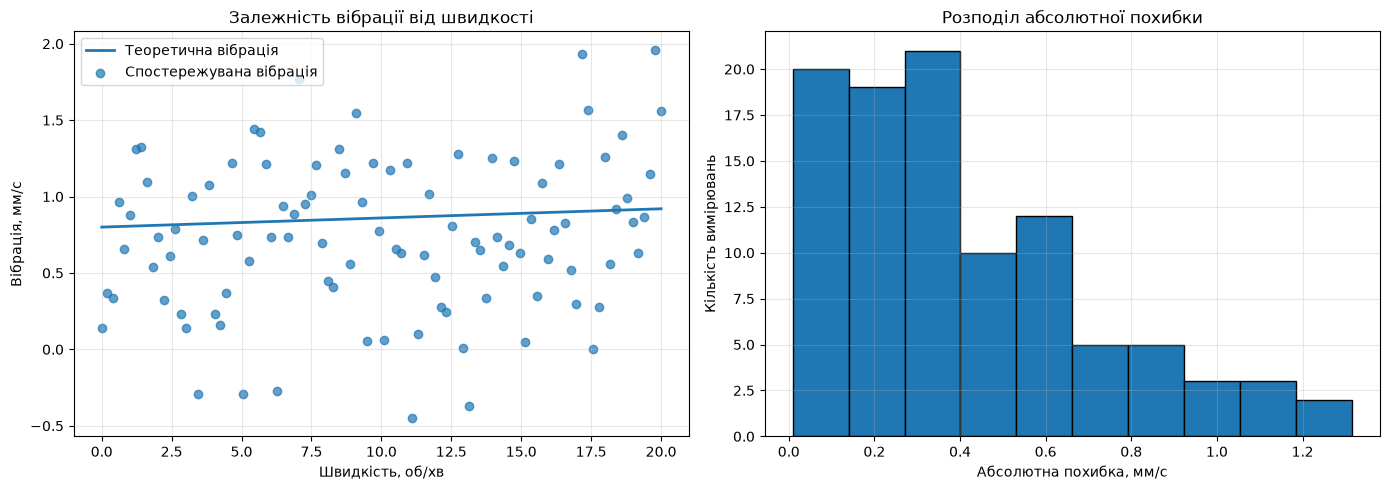

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Перший графік
axes[0].plot(
    df_clean["x"],
    df_clean["y_true"],
    label="Теоретична вібрація",
    linewidth=2
)

axes[0].scatter(
    df_clean["x"],
    df_clean["y_observed"],
    label="Спостережувана вібрація",
    alpha=0.7
)

axes[0].set_title("Залежність вібрації від швидкості")
axes[0].set_xlabel("Швидкість, об/хв")
axes[0].set_ylabel("Вібрація, мм/с")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Другий графік
axes[1].hist(
    df_clean["absolute_error"],
    bins=10,
    edgecolor="black"
)

axes[1].set_title("Розподіл абсолютної похибки")
axes[1].set_xlabel("Абсолютна похибка, мм/с")
axes[1].set_ylabel("Кількість вимірювань")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

На першому графіку показано теоретичну лінійну залежність вібрації від швидкості та фактичні спостереження з випадковим шумом.

На другому графіку показано розподіл абсолютної похибки. Це дозволяє оцінити, наскільки сильно окремі вимірювання відхиляються від теоретичних значень.

In [17]:
fig.savefig("Lab2_plot.png", dpi=300, bbox_inches="tight")

print("Рисунок збережено у файл Lab2_plot.png")

Рисунок збережено у файл Lab2_plot.png


Побудований рисунок збережено у форматі PNG з роздільною здатністю 300 dpi, що забезпечує достатню якість для подання лабораторної роботи.

In [18]:
df_clean.to_csv("Lab2_results.csv", index=False)

df_clean.to_parquet("Lab2_results.parquet", index=False)

summary.to_csv("Lab2_summary.csv", index=False)

print("Файли успішно збережено:")
print("- Lab2_results.csv")
print("- Lab2_results.parquet")
print("- Lab2_summary.csv")

Файли успішно збережено:
- Lab2_results.csv
- Lab2_results.parquet
- Lab2_summary.csv


Очищені дані збережено у форматах CSV та Parquet. Окремо збережено агреговану таблицю з результатами групування у форматі CSV.

# Висновок

У ході лабораторної роботи було опрацьовано основні можливості бібліотек NumPy, pandas та Matplotlib для підготовки, аналізу та візуалізації даних.

За допомогою NumPy було створено 100 значень швидкості від 0 до 20 об/хв, обчислено теоретичні значення вібрації двигуна за формулою ŷ = 0.006x + 0.8 та змодельовано випадковий шум із нормальним розподілом і стандартним відхиленням σ = 0.6.

Було продемонстровано роботу з масивами NumPy: індексацію, зрізи, булеву фільтрацію, копіювання фрагмента, видалення елементів та статистичну агрегацію.

За допомогою pandas створено DataFrame, виконано його первинний аналіз, штучно додано пропущені значення та дубльований рядок, після чого дані було очищено. Пропуски заповнено медіаною, а дубльований рядок видалено. Також було продемонстровано використання `loc`, `iloc`, булевої фільтрації, сортування та групування даних.

Для оцінювання похибок обчислено MAE та MSE. MAE виражається в мм/с, а MSE — у (мм/с)².

За допомогою Matplotlib побудовано графік теоретичної та спостережуваної вібрації, а також гістограму абсолютних похибок. Результати було збережено у файли CSV, Parquet та PNG.

Таким чином, у роботі було виконано повний базовий цикл підготовки та аналізу даних: від генерації та очищення до статистичного аналізу, оцінювання похибок, візуалізації та збереження результатів.